## Creating a Dataset for Container Defects and Container ID

In [1]:
import cv2
import os

def extract_frames(video_path, output_folder, interval=30):
    cap = cv2.VideoCapture(video_path)
    count = 0
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break
        if count % interval == 0:
            cv2.imwrite(f"{output_folder}/frame_{count}.jpg", frame)
        count += 1
    cap.release()

In [16]:
import cv2
import os
from pathlib import Path
from tqdm import tqdm  # optional, for progress bar

def extract_frames_every_nth(input_folder, output_folder, step=10, extensions=('.mp4', '.avi', '.MOV', '.mkv', '.flv')):
    """
    Extract every `step`-th frame from all videos in input_folder and save to output_folder.

    Parameters:
        input_folder (str or Path): Path containing video files.
        output_folder (str or Path): Destination folder for extracted frames.
        step (int): Extract every `step`-th frame (default 10).
        extensions (tuple): File extensions to consider as videos.
    """
    input_path = Path(input_folder)
    output_path = Path(output_folder)
    output_path.mkdir(parents=True, exist_ok=True)

    # Gather all video files recursively
    video_files = []
    for ext in extensions:
        video_files.extend(input_path.rglob(f'*{ext}'))

    if not video_files:
        print(f"No video files found in {input_folder} with extensions {extensions}")
        return

    print(f"Found {len(video_files)} video(s).")

    # Process each video
    for video_file in tqdm(video_files, desc="Processing videos"):
        cap = cv2.VideoCapture(str(video_file))
        if not cap.isOpened():
            print(f"Warning: Could not open {video_file}. Skipping.")
            continue

        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        # Optional: skip if video is too short
        if total_frames < step:
            print(f"Video {video_file.name} has only {total_frames} frames (< step={step}), skipping.")
            cap.release()
            continue

        # Prepare subfolder inside output (preserve relative path from input_folder)
        rel_path = video_file.parent.relative_to(input_path) if video_file.parent != input_path else Path('')
        save_subdir = output_path / rel_path
        save_subdir.mkdir(parents=True, exist_ok=True)

        frame_count = 0
        saved_count = 0

        while True:
            ret, frame = cap.read()
            if not ret:
                break

            if frame_count % step == 0:
                # Construct filename: original_video_name_frameXXXX.jpg
                out_filename = f"{video_file.stem}_frame{frame_count:06d}.jpg"
                out_path = save_subdir / out_filename
                cv2.imwrite(str(out_path), frame)
                saved_count += 1

            frame_count += 1

        cap.release()
        print(f"  {video_file.name}: extracted {saved_count} frames (every {step}th of {total_frames} total)")

    print(f"\n✅ Done. Frames saved in {output_folder}")

In [19]:
if __name__ == "__main__":
    extract_frames_every_nth(
        input_folder="CV_Anton_All_Files/",
        output_folder="new_dataset",
        step=10
    )

Found 24 video(s).


Processing videos:   4%|▍         | 1/24 [00:10<03:54, 10.18s/it]

  Copia de IMG_3910.MOV: extracted 116 frames (every 10th of 1158 total)


Processing videos:   8%|▊         | 2/24 [00:10<01:42,  4.67s/it]

  Copia de IMG_3905.MOV: extracted 9 frames (every 10th of 85 total)


...

  Copia de IMG_3918.MOV: extracted 30 frames (every 10th of 291 total)


Processing videos:  96%|█████████▌| 23/24 [02:04<00:05,  5.17s/it]

  Copia de IMG_3926.MOV: extracted 20 frames (every 10th of 194 total)


Processing videos: 100%|██████████| 24/24 [02:09<00:00,  5.38s/it]

  Copia de IMG_3923.MOV: extracted 38 frames (every 10th of 378 total)

✅ Done. Frames saved in new_dataset


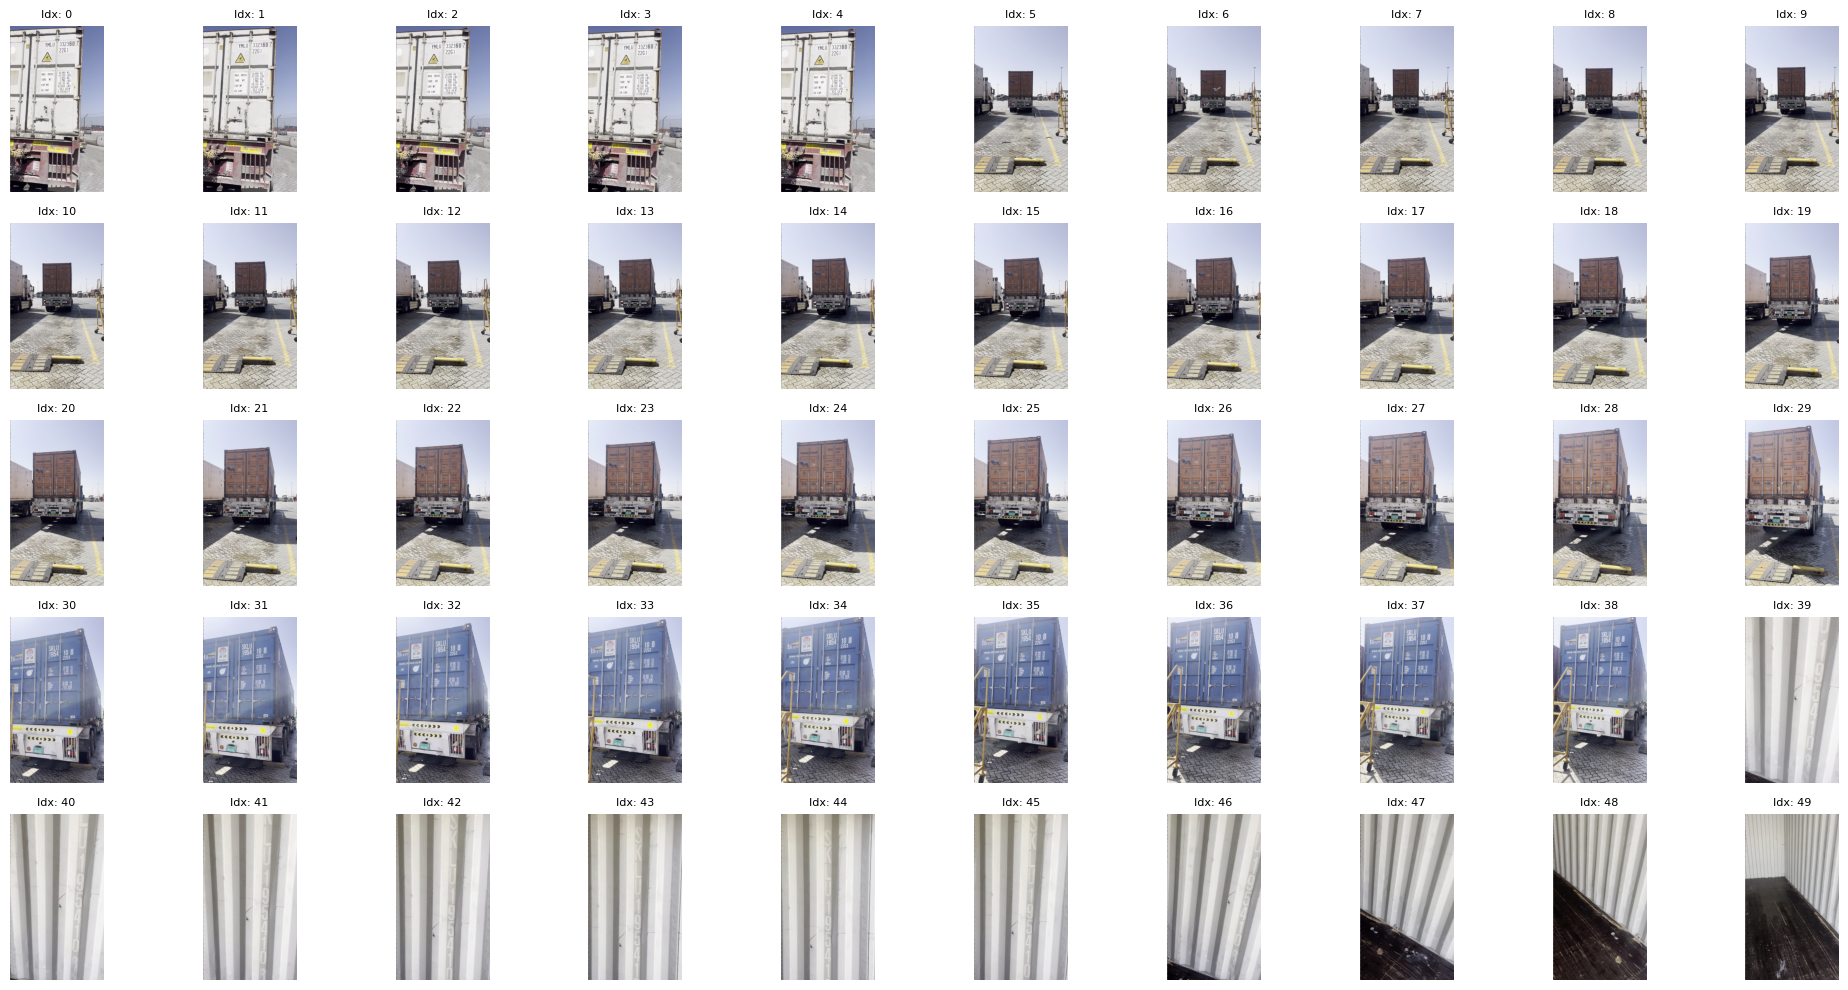

In [21]:
import matplotlib.pyplot as plt
import cv2
import os
from pathlib import Path

def plot_extracted_frames(folder_path, num_images=50):
    # Gather all jpg files in the folder
    images = [f for f in os.listdir(folder_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    images.sort()  # Keep them in frame order
    
    # Take only the first 50 (or whatever is available)
    images_to_show = images[:num_images]
    n = len(images_to_show)
    
    if n == 0:
        print("No images found in the specified directory.")
        return

    # Calculate grid size (10 columns, rows depend on count)
    cols = 10
    rows = (n + cols - 1) // cols
    
    plt.figure(figsize=(20, 2 * rows))
    
    for i, img_name in enumerate(images_to_show):
        img_path = os.path.join(folder_path, img_name)
        
        # Load image and convert from BGR (OpenCV) to RGB (Matplotlib)
        img = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img_rgb)
        
        # Add a small title with the frame number/index
        plt.title(f"Idx: {i}", fontsize=8)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Usage
# folder = 'extracted_frames/subfolder_name' # if you used the recursive script
folder = 'new_dataset' 
plot_extracted_frames(folder, num_images=50)